In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/cleaned/city_day_cleaned.csv')
df['Date'] = pd.to_datetime(df['Date'])

sns.set_style('whitegrid')
print("✅ Cleaned data loaded:", df.shape)

Matplotlib is building the font cache; this may take a moment.


✅ Cleaned data loaded: (24850, 21)


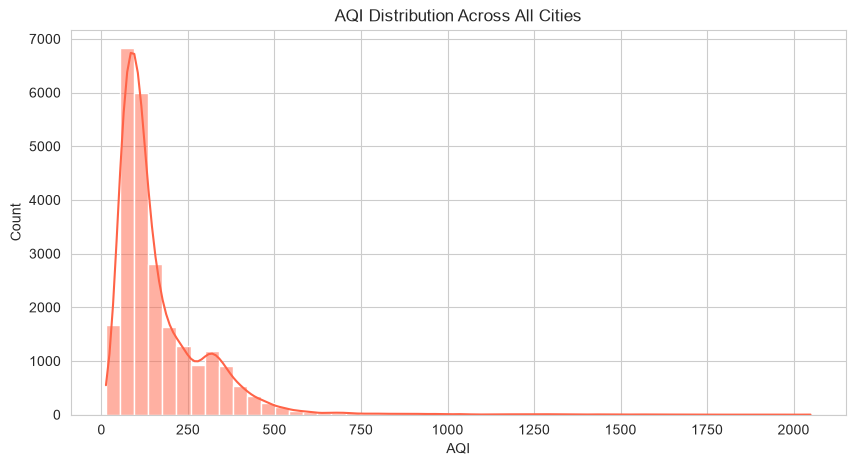

In [2]:
plt.figure(figsize=(10,5))
sns.histplot(df['AQI'], bins=50, kde=True, color='tomato')
plt.title('AQI Distribution Across All Cities')
plt.xlabel('AQI')
plt.savefig('../reports/01_aqi_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\parma\AppData\Local\Temp\ipykernel_19448\532372684.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='AQI_Bucket', order=order, palette='RdYlGn_r')


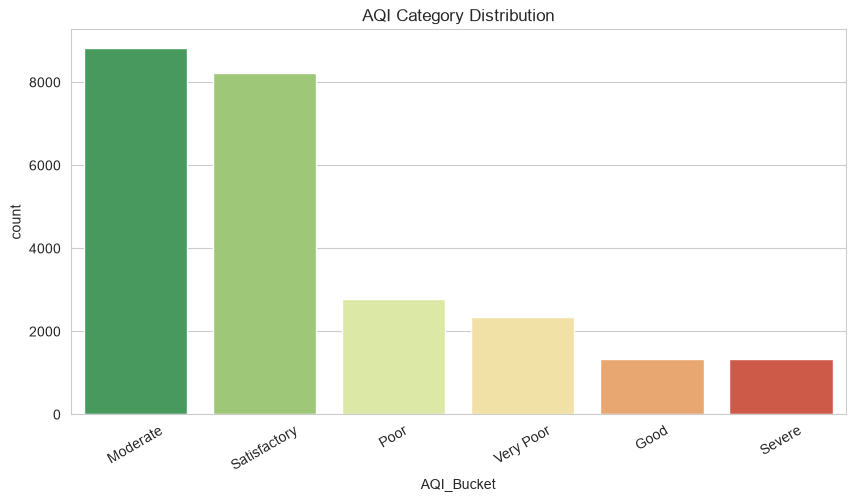

In [3]:
plt.figure(figsize=(10,5))
order = df['AQI_Bucket'].value_counts().index
sns.countplot(data=df, x='AQI_Bucket', order=order, palette='RdYlGn_r')
plt.title('AQI Category Distribution')
plt.xticks(rotation=30)
plt.savefig('../reports/02_aqi_bucket_counts.png', dpi=150, bbox_inches='tight')
plt.show()

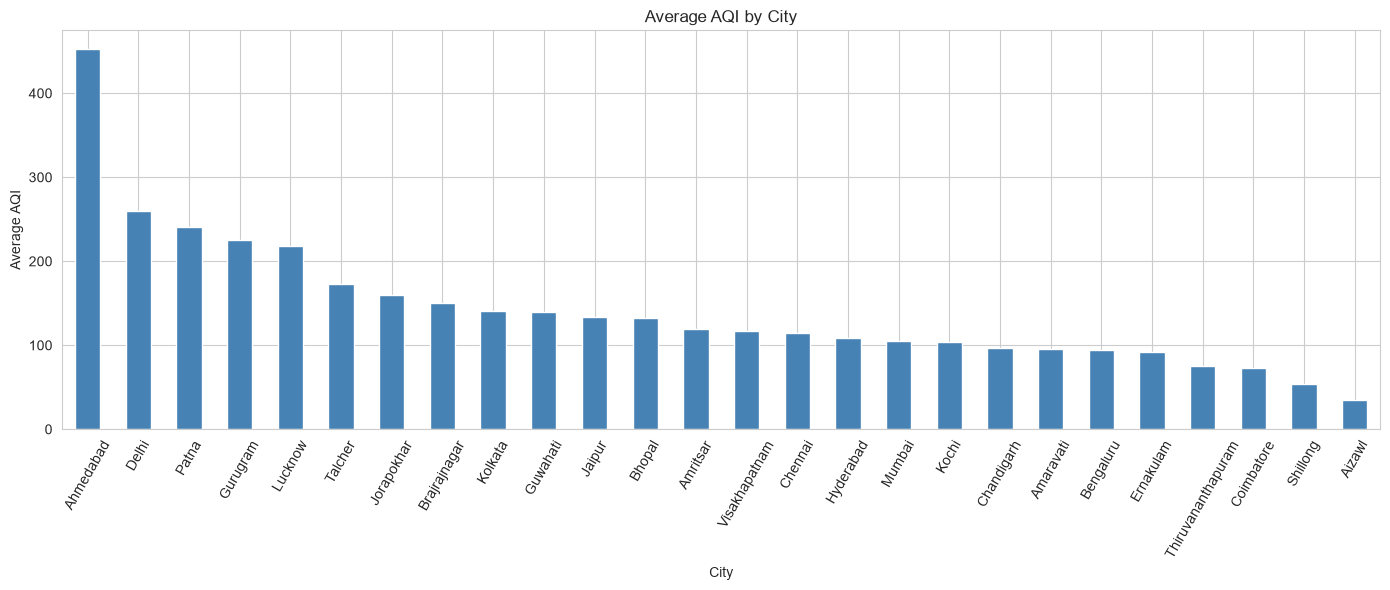

City
Ahmedabad             452.122939
Delhi                 259.487744
Patna                 240.782042
Gurugram              225.123882
Lucknow               217.973059
Talcher               172.886819
Jorapokhar            159.251621
Brajrajnagar          150.280505
Kolkata               140.566313
Guwahati              140.111111
Jaipur                133.679159
Bhopal                132.827338
Amritsar              119.920959
Visakhapatnam         117.269855
Chennai               114.502654
Hyderabad             109.207447
Mumbai                105.352258
Kochi                 104.284810
Chandigarh             96.498328
Amaravati              95.299643
Bengaluru              94.318325
Ernakulam              92.359477
Thiruvananthapuram     75.878327
Coimbatore             73.023256
Shillong               53.795122
Aizawl                 34.765766
Name: AQI, dtype: float64


In [4]:
city_aqi = df.groupby('City')['AQI'].mean().sort_values(ascending=False)

plt.figure(figsize=(14,6))
city_aqi.plot(kind='bar', color='steelblue')
plt.title('Average AQI by City')
plt.ylabel('Average AQI')
plt.xticks(rotation=60)
plt.tight_layout()
plt.savefig('../reports/03_avg_aqi_by_city.png', dpi=150, bbox_inches='tight')
plt.show()

print(city_aqi)

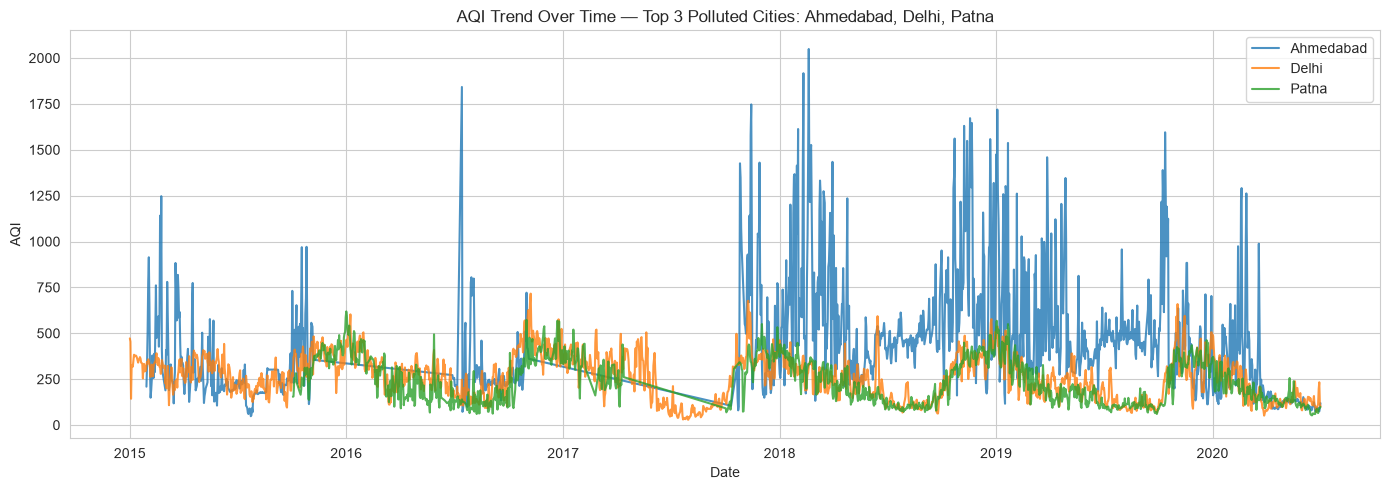

In [5]:
top3 = city_aqi.head(3).index.tolist()

plt.figure(figsize=(14,5))
for city in top3:
    temp = df[df['City']==city].groupby('Date')['AQI'].mean()
    plt.plot(temp.index, temp.values, label=city, alpha=0.8)

plt.title(f'AQI Trend Over Time — Top 3 Polluted Cities: {", ".join(top3)}')
plt.xlabel('Date'); plt.ylabel('AQI')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/04_aqi_trend_top3.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\parma\AppData\Local\Temp\ipykernel_19448\2667729431.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='AQI', order=['Winter','Spring','Summer','Monsoon'], palette='coolwarm')


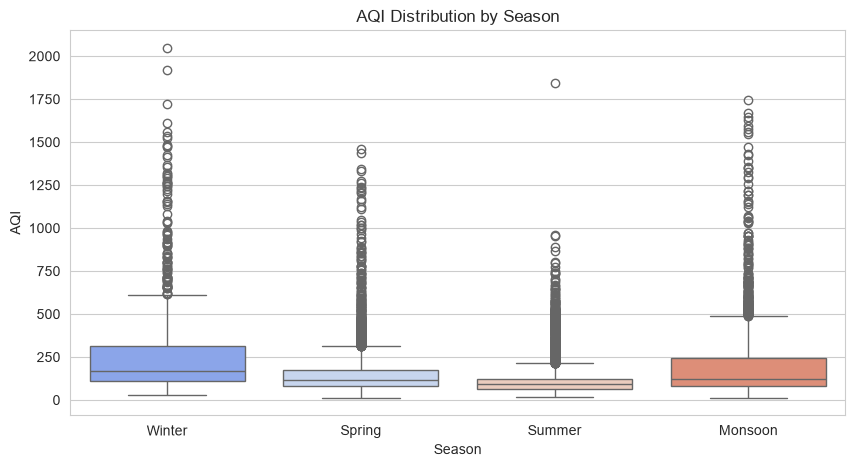

In [6]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Season', y='AQI', order=['Winter','Spring','Summer','Monsoon'], palette='coolwarm')
plt.title('AQI Distribution by Season')
plt.savefig('../reports/05_aqi_by_season.png', dpi=150, bbox_inches='tight')
plt.show()

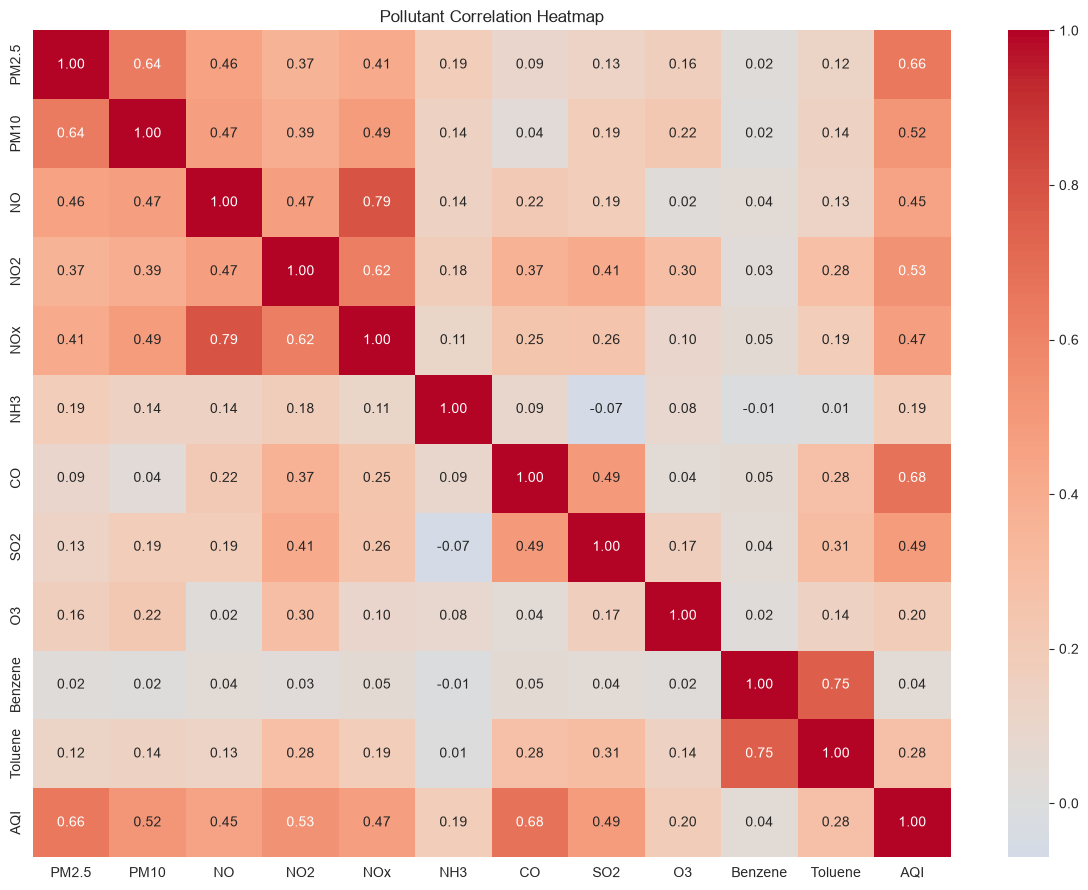


--- Correlation with AQI (sorted) ---
AQI        1.000000
CO         0.677359
PM2.5      0.656749
NO2        0.534919
PM10       0.517738
SO2        0.485978
NOx        0.470999
NO         0.451285
Toluene    0.280726
O3         0.197119
NH3        0.188133
Benzene    0.044423
Name: AQI, dtype: float64


In [7]:
numeric_cols = ['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3',
                 'Benzene','Toluene','AQI']

plt.figure(figsize=(12,9))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Pollutant Correlation Heatmap')
plt.tight_layout()
plt.savefig('../reports/06_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n--- Correlation with AQI (sorted) ---")
print(corr['AQI'].sort_values(ascending=False))

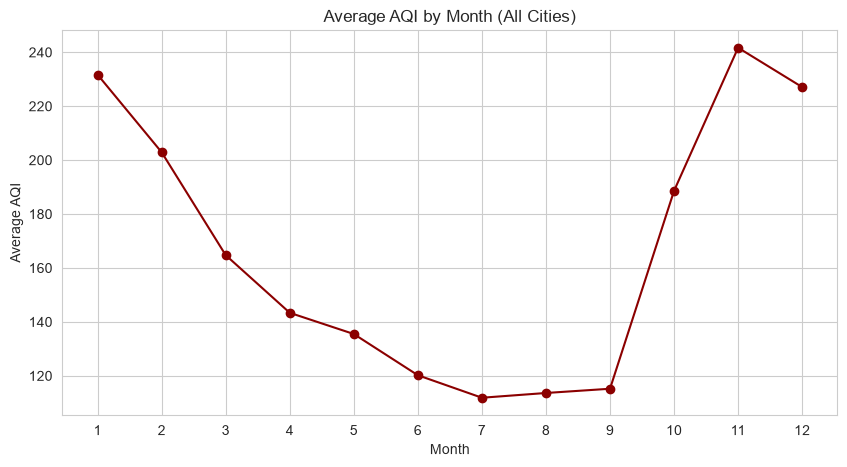

In [8]:
monthly_avg = df.groupby('Month')['AQI'].mean()

plt.figure(figsize=(10,5))
monthly_avg.plot(kind='line', marker='o', color='darkred')
plt.title('Average AQI by Month (All Cities)')
plt.xlabel('Month'); plt.ylabel('Average AQI')
plt.xticks(range(1,13))
plt.grid(True)
plt.savefig('../reports/07_monthly_aqi_trend.png', dpi=150, bbox_inches='tight')
plt.show()